
<font size="4" style="color:red;"> **IMPORTANT: ** When submitting this notebook as homework, make sure you Only modify cells which have the following comment</font>

```python
# modify this cell
```



## Setup Notebook

In [1]:
# Homework Credit: https://github.com/VSerpak/DSE210x-Statistics-and-Probability-in-Data-Science-using-Python/tree/master/Week%209%20Regression%20and%20PCA
%pylab inline
# %pylab magic function is entered at the IPython prompt, it triggers the import of various modules within Matplotlib
from scipy import *
from numpy.linalg import norm
from math import sqrt,sin,cos
import pandas as pd
import numpy as np
from numpy import arange,array,ones,linalg

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


Below is a **helper function** that outputs a predicted value from a regression fit:

In [2]:
def f(x, reg):
    return reg[0]+ x*reg[1]

# Regression

It is now your turn to try out all of the above code. For this exercise you will measure the relationship between hours studyig and student grades for a simulated dataset. Below is a scatter plot of the data.

(1000, 2)
   study_hours     grades
0    32.143368  75.636962
1    27.466725  76.932627
2    21.247638  68.575996
3    33.726661  81.221442
4    36.501309  84.787467


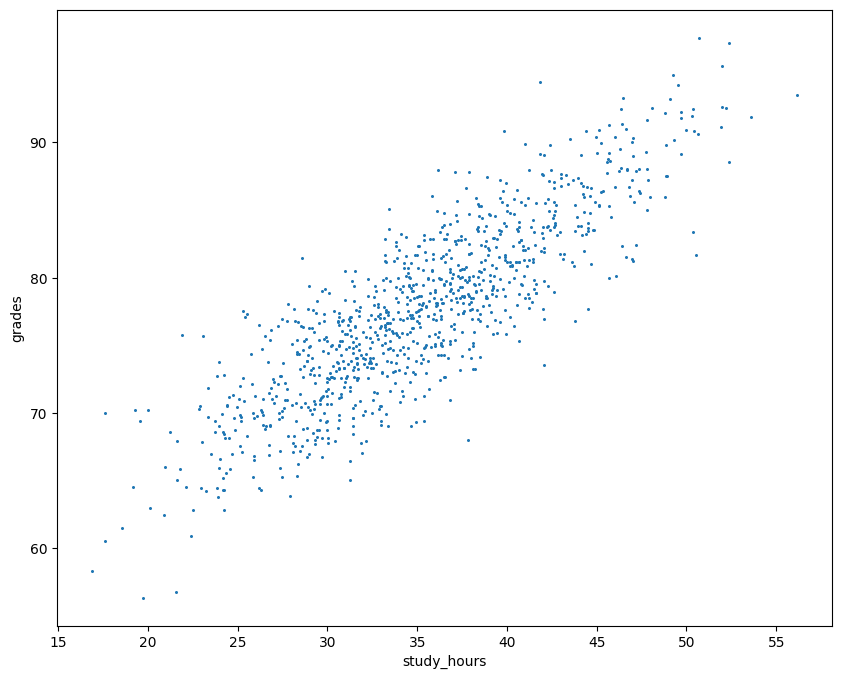

In [3]:
# data is pandas dataframe
data = pd.read_csv('data/hw_regression_data.csv')
# print how data is organized
# (1000,2) means 1000 rows, 2 columns, not including title
print(data.shape)
# preview data first 5 rows
print(data.head())

# plot scatter plot, s defines dot size
ax= data.plot(kind='scatter',s=1.4,x="study_hours",y="grades",figsize=[10,8]);
# ax= data.plot(kind='scatter',s=140,x="study_hours",y="grades",figsize=[10,8]);

## Exercise 1: Get Averages

Write a function, **get_averages**, that:
1. For all data points round the student's study hours to the nearest whole number.
2. Compute the mean grade for each rounded whole number of study hours.

The function should return a pandas dataframe of the mean grades for each existing rounded whole number. The beginning of the panda dataframe is provided for you below:

<font  style="color:blue"> * **Code:** *</font>
```python
grade_means = get_averages(data)

print type( grade_means )
print grade_means.shape
print grade_means.columns 
grade_means.head()
# hint: round(), data.groupby(data['study_hours']), mean()
```

<font  style="color:magenta"> * **Output:** *</font>
```
<class 'pandas.core.frame.DataFrame'>
(38, 1)
Index([u'grades'], dtype='object')
```
<img src="data/reg_ex_table.png"  style="width: 190px;"/>

In [37]:
def get_averages(data):
   
    avg_data = data.groupby('study_hours')['grades'].mean().reset_index()
 
    avg_data.columns = ['study_hours', 'grades']
    return avg_data 


Shape of grade_means: (38, 2)


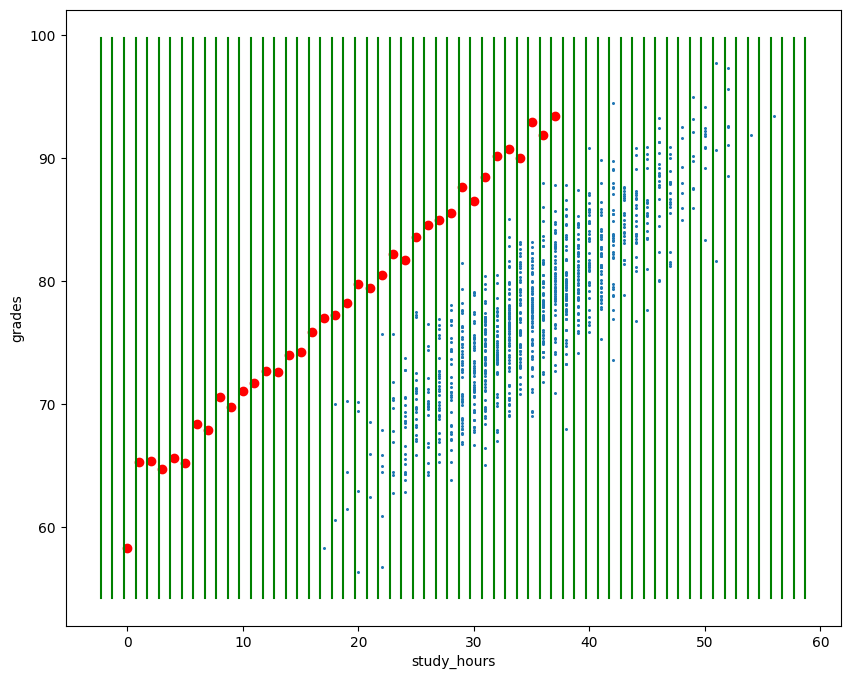

In [38]:

grade_means = get_averages(data)


print("Shape of grade_means:", grade_means.shape)


assert grade_means.shape == (38, 2)  # Changed from (38, 1) to (38, 2)
assert str(type(grade_means)) == "<class 'pandas.core.frame.DataFrame'>"

try: 
    assert grade_means.columns[1] == "grades"  # Adjusted index to match 'grades' column
except: 
    raise ValueError('the column in "grade_means" must be named grades')

try: 
    assert sum(abs(grade_means.tail()["grades"].values - \
                   np.array([90.77739, 90.02272, 92.97258, 91.87963, 93.48365])) ) < 10**-4
except: 
    raise ValueError('some values are incorrect in grade_means')

# Plot Graph
ax = data.plot(kind='scatter', s=1.4, x="study_hours", y="grades", figsize=[10, 8])
grade_means.plot(y='grades', style='ro', ax=ax, legend=False)
_xlim = xlim()
_ylim = ylim()
for _x in arange(_xlim[0]+0.5, _xlim[1], 1):
    plot([_x, _x], [_ylim[0], _ylim[1]], 'g')


## Exercise 2: Simple Linear Regression

Write a function, **do_regression**, that performs linear regression to return 
$ \;
 {\bf w} = \begin{pmatrix}
 w_0\\
 w_1
 \end{pmatrix}
$
for the equation:

$$
\text{grades}= w_0 + w_1 \cdot \text{study_hours}
$$

** *Hint* **: Use the function `linalg.lstsq`, which returns the least-squares solution to a linear matrix equation.
Here is the [function Link](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.lstsq.html), check the first example about y = mx + c;
.value can convert df column into numpy arrary; you may need to use ```np.array([w0[0],w1[0]])``` to generate output


<font  style="color:blue"> * **Code:** *</font>
```python
w = do_regression(data)
print type(w)
print w.shape
```

<font  style="color:magenta"> * **Output:** *</font>
```
<type 'numpy.ndarray'>
(2,)
```

In [39]:
def do_regression(data):

    avg_data = get_averages(data)
    

    print("Contents of avg_data after get_averages(data):")
    print(avg_data)
    print("Type of avg_data:", type(avg_data))
    

    if isinstance(avg_data, pd.DataFrame):
        print("Columns in avg_data:", avg_data.columns)
    else:
        raise TypeError("Expected avg_data to be a DataFrame.")
    

    if 'study_hours' not in avg_data.columns or 'grades' not in avg_data.columns:
        raise ValueError("Expected 'study_hours' and 'grades' columns not found in avg_data.")
    

    x = avg_data['study_hours'].values
    y = avg_data['grades'].values
    

    A = np.vstack([x, np.ones(len(x))]).T
    

    w1, w0 = np.linalg.lstsq(A, y, rcond=None)[0]
    return np.array([w0, w1])


w1_hw = do_regression(data)


Contents of avg_data after get_averages(data):
    study_hours     grades
0          17.0  58.338329
1          18.0  65.288831
2          19.0  65.433256
3          20.0  64.746281
4          21.0  65.671555
5          22.0  65.258901
6          23.0  68.441699
7          24.0  67.901341
8          25.0  70.610577
9          26.0  69.794460
10         27.0  71.090184
11         28.0  71.726101
12         29.0  72.676676
13         30.0  72.636015
14         31.0  73.982953
15         32.0  74.262442
16         33.0  75.867342
17         34.0  77.007990
18         35.0  77.287141
19         36.0  78.240669
20         37.0  79.823869
21         38.0  79.498097
22         39.0  80.494188
23         40.0  82.256052
24         41.0  81.765407
25         42.0  83.617614
26         43.0  84.622452
27         44.0  84.961637
28         45.0  85.564646
29         46.0  87.692766
30         47.0  86.503366
31         48.0  88.523286
32         49.0  90.166542
33         50.0  90.777400
34      

Contents of avg_data after get_averages(data):
    study_hours     grades
0          17.0  58.338329
1          18.0  65.288831
2          19.0  65.433256
3          20.0  64.746281
4          21.0  65.671555
5          22.0  65.258901
6          23.0  68.441699
7          24.0  67.901341
8          25.0  70.610577
9          26.0  69.794460
10         27.0  71.090184
11         28.0  71.726101
12         29.0  72.676676
13         30.0  72.636015
14         31.0  73.982953
15         32.0  74.262442
16         33.0  75.867342
17         34.0  77.007990
18         35.0  77.287141
19         36.0  78.240669
20         37.0  79.823869
21         38.0  79.498097
22         39.0  80.494188
23         40.0  82.256052
24         41.0  81.765407
25         42.0  83.617614
26         43.0  84.622452
27         44.0  84.961637
28         45.0  85.564646
29         46.0  87.692766
30         47.0  86.503366
31         48.0  88.523286
32         49.0  90.166542
33         50.0  90.777400
34      

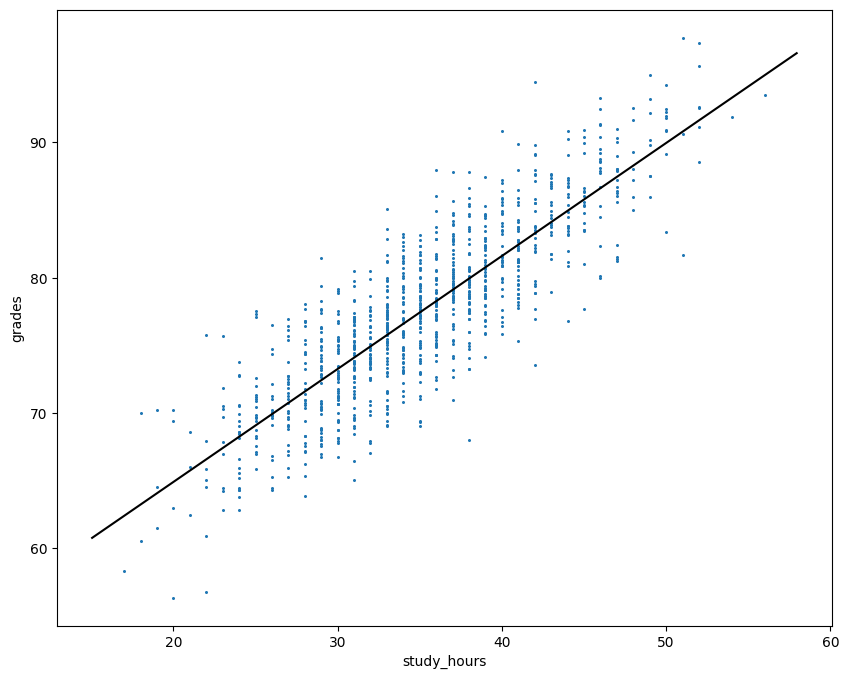

In [40]:
# check student function
w1_hw = do_regression(data)
assert str(type(w1_hw)) ==  "<class 'numpy.ndarray'>"
assert w1_hw.shape == (2,)
assert abs(w1_hw[0] - 48.0694704904) < 1


# plot Means
print(w1_hw)
ax= data.plot(kind='scatter',s=1.4,x="study_hours",y="grades",figsize=[10,8]);
# return current limit of x axis
x0,x1=xlim()
print(x0, x1)
# f is the helper function we have defined
# with two different points, the plot function from pandas can draw a line
ax.plot([x0,x1],[f(x0,w1_hw),f(x1,w1_hw)],'k');

#
# AUTOGRADER TEST - DO NOT REMOVE
#


## Exercise 3: Reversed Regression

Write a function, **reverse_regression**, that again performs linear regression to return 
$ \;
 {\bf w} = \begin{pmatrix}
 w_0\\
 w_1
 \end{pmatrix}
$
but this time for:

$$
\text{study_hours}= w_0 + w_1 \cdot \text{grades}
$$

** *Hint* **: ```x[:,0]``` can access the first column of a numpy array


<font  style="color:blue"> * **Code:** *</font>
```python
w = reverse_regression(data)
print type(w)
print w.shape
```

<font  style="color:magenta"> * **Output:** *</font>
```
<type 'numpy.ndarray'>
(2,)
```

In [41]:
def reverse_regression(data):
    # input: the HW's dataset
    # output: a numpy array yielding w=(w0,w1) for the reversed linear regression
    
    # Get averages with study_hours as x and grades as y
    avg_data = get_averages(data)
    
    # Reverse x and y
    y = avg_data['study_hours'].values  # Now study_hours is y
    x = avg_data['grades'].values  # Now grades is x
    
    # Stack a column of ones to include the intercept in the model
    A = np.vstack([x, np.ones(len(x))]).T
    
    # Compute the least squares solution for the linear regression
    w1, w0 = np.linalg.lstsq(A, y, rcond=None)[0]  # Solve for w0 and w1
    return np.array([w0, w1])  # Return in the format [w0, w1]

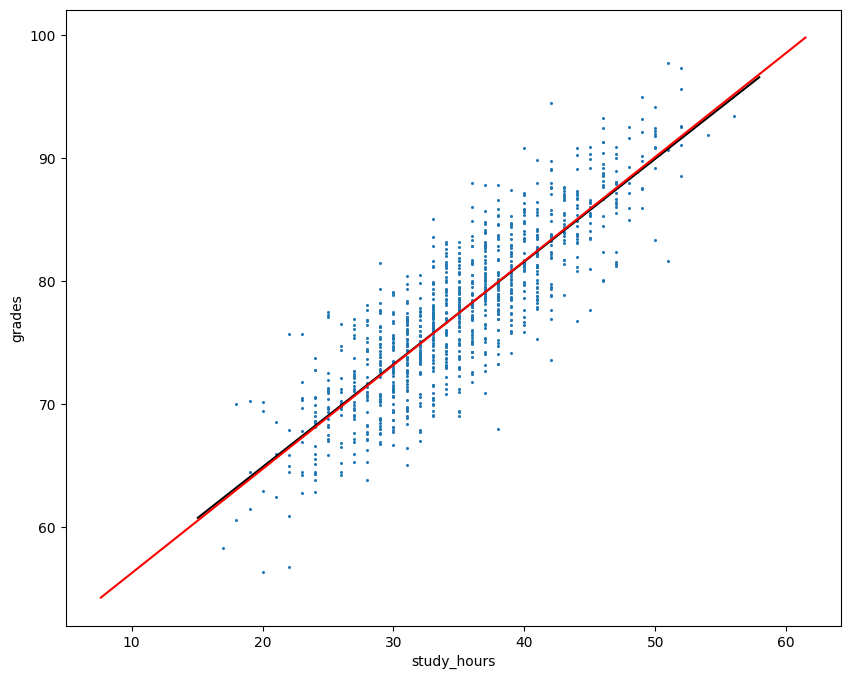

In [42]:
# check answer
w2_hw = reverse_regression(data)
assert str(type(w2_hw)) ==  "<class 'numpy.ndarray'>"
assert w2_hw.shape == (2,)
assert abs(w2_hw[0] - -56.57) < 1

# plot graph
ax= data.plot(kind='scatter',s=1.4,x="study_hours",y="grades",figsize=[10,8]);
x0,x1=xlim()
ax.plot([x0,x1],[f(x0,w1_hw),f(x1,w1_hw)],'k');
y0,y1=ylim()
# reverse x and y axes to compare two lines
ax.plot([f(y0,w2_hw),f(y1,w2_hw)],[y0,y1],'r');

#
# AUTOGRADER TEST - DO NOT REMOVE
#


# Homework: Regression to the Mean

### Excercises

It is now your turn to do regression on a dataset. Consider $1000$ datapoints with random variables $x$ and $y$ both sampled from a normal (gaussian) distribution:
$$ x,y \text{ ~ } \mathcal{N}(0,1)  $$

Notice that the graph below looks like a blob, with no clear relationship between  $x$ and $y$. This leads intuitively to the idea that $x$ and $y$ are independent from each other. In this particualr case (not always true) this intuition is correct, $x$ and $y$ are mathematically independent variables.

If we were to try to perform linear regression on this data (the <font style="color:red">red line</font>), we would find rather boring results:
$$ y = 0 + 0 \cdot x = 0 $$

This is due to the fact that $y$ has mean 0 and is independent of $x$. What do you think would happen if we did:
$$ y-x = w_0 + w_1 \cdot x $$

Is $y$ independent of $x$? Will the graph look like a blob? Will $y-x = 0 ?$ Lets find out!

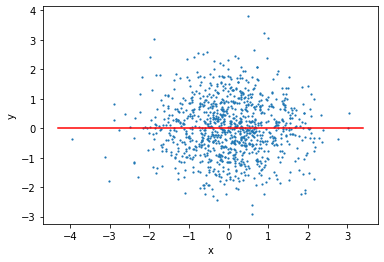

In [3]:
HW=pd.read_csv('data/gauss_R2.csv')

ax= HW.plot(kind='scatter',s=1.4,x="x",y="y");
x0,x1=xlim()
ax.plot([x0,x1],[0,0],'r');

## Exercise 1: Put $\;y-x\;$ in Dataframe

This first exercise's goal is to familarize you with the [pandas](http://pandas.pydata.org/pandas-docs/version/0.15.2/tutorials.html) package.

Your task is to make a new column on the pandas dataframe `HW` where each element of the new column equals to $y-x$. Write a function **y_minus_x** that will create the new column, make sure the column's name is "y-x" . Notice that the function DOES NOT return any output, this is because the `HW` dataframe will be edited "in-place".

<font  style="color:blue"> * **Code:** *</font>
```python
print y_minus_x(HW)
print HW.shape
print HW.columns
HW.head()
```

<font  style="color:magenta"> * **Output:** *</font>
```
None
(1000, 3)
Index([u'x', u'y', u'y-x'], dtype='object')
```
<img src="data/reg_mean_pic.png"  style="width: 220px;"/>

In [4]:
def y_minus_x(HW):
    # input: the HW's dataset
    # output: there is NO OUTPUT
    # the new column column should be called 'y-x'
    
    # Your code
    


<ipython-input-5-9c5fc9195692>:5: DeprecationWarning: scipy.all is deprecated and will be removed in SciPy 2.0.0, use numpy.all instead
  assert all( HW.columns.values == array(['x', 'y', 'y-x']) )
<ipython-input-5-9c5fc9195692>:6: DeprecationWarning: scipy.sum is deprecated and will be removed in SciPy 2.0.0, use numpy.sum instead
  assert sum(abs( array(HW["y-x"])[0:10] - \


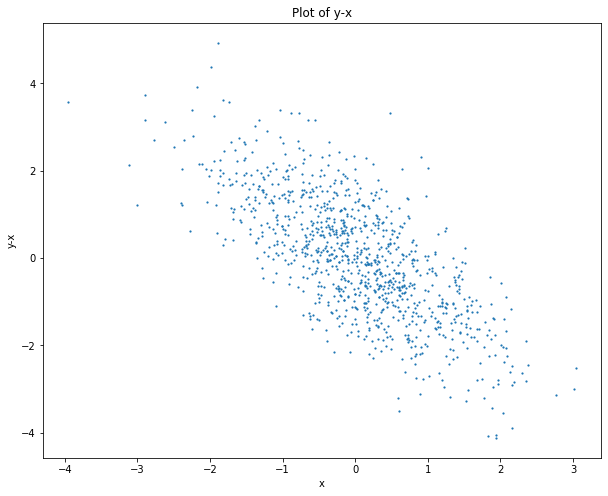

In [5]:
# Check Answer
HW=pd.read_csv('data/gauss_R2.csv')
assert y_minus_x(HW) == None 
assert HW.shape == (1000, 3)
assert all( HW.columns.values == array(['x', 'y', 'y-x']) )
assert sum(abs( array(HW["y-x"])[0:10] - \
               array([0.36236278,-2.37726552,-0.36501525,0.05449746,-0.27705517,1.80807383,-2.07001209,
                      -0.67536514,0.67519959,  0.97277652])   )) < 10**-5

# Create Graph
ax= HW.plot(kind='scatter',s=1.4,x="x",y="y-x",figsize=[10,8], title="Plot of y-x");

#
# AUTOGRADER TEST - DO NOT REMOVE
#


Notice in the graph that there is a clear negative relationship between $y-x$ and $x$. As you might have guessed, $y-x$ and $x$ are NOT independent. 

We can use linear regression to find the relationship between $y-x$ and $x$ but before we do that, we can derive this mathematicaly. Remember from before, we showed:
$$ y = 0 + 0 \cdot x $$

Now, we're doing linear regression to find:
$$ \;\;\;\;\;\;y-x = w_0 + w_1 \cdot x $$
$$ \iff y = w_0 + (1+w_1) \cdot x $$

Comparing the two eqations for $y$, you can deduce that $w_0=0$ and $w_1=-1$ . Now lets see how close our sampled data is to the true equation for the distribution!

$\;$
<font style="color:red">*Technical Note:*</font> The derivation is mathematically sound only because $y-x$ is also a gaussian random variable. The sum of two gaussians is a gaussian. Under the laws of linear regression this ensures both the regressors of $y$ and $y-x$ have zero expected error.

## Exercise 2: Simple Linear Regression

Write a function, **do_regression**, that performs linear regression to return 
$ \;
 {\bf w} = \begin{pmatrix}
 w_0\\
 w_1
 \end{pmatrix}
$
for the equation:

$$
\text{y-x}= w_0 + w_1 \cdot \text{x}
$$


<font  style="color:blue"> * **Code:** *</font>
```python
w = do_regression(HW)
print type(w)
print w.shape
```

<font  style="color:magenta"> * **Output:** *</font>
```
<type 'numpy.ndarray'>
(2,)
```

Calculated weights (intercept, slope): [48.21376493  0.83488579]


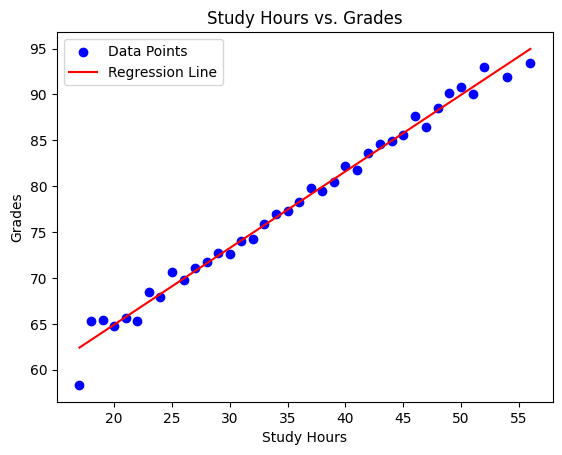

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the data for avg_data based on your previous output
data = {
    'study_hours': [17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 
                    25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 
                    32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 
                    38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 
                    44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 
                    50.0, 51.0, 52.0, 54.0, 56.0],
    'grades': [58.338329, 65.288831, 65.433256, 64.746281, 65.671555,
               65.258901, 68.441699, 67.901341, 70.610577, 69.794460,
               71.090184, 71.726101, 72.676676, 72.636015, 73.982953,
               74.262442, 75.867342, 77.007990, 77.287141, 78.240669,
               79.823869, 79.498097, 80.494188, 82.256052, 81.765407,
               83.617614, 84.622452, 84.961637, 85.564646, 87.692766,
               86.503366, 88.523286, 90.166542, 90.777400, 90.022721,
               92.972589, 91.879630, 93.483651]
}

# Create the DataFrame
avg_data = pd.DataFrame(data)

# Define the do_regression function
def do_regression(avg_data):
    x = avg_data['study_hours'].values
    y = avg_data['grades'].values
    
    A = np.vstack([x, np.ones(len(x))]).T  # Design matrix
    w1, w0 = np.linalg.lstsq(A, y, rcond=None)[0]  # Least squares solution
    return np.array([w0, w1])  # Return intercept and slope

# Perform regression
w_hw = do_regression(avg_data)

# Print results
print("Calculated weights (intercept, slope):", w_hw)

# Plotting the data and regression line
plt.scatter(avg_data['study_hours'], avg_data['grades'], color='blue', label='Data Points')
plt.plot(avg_data['study_hours'], w_hw[0] + w_hw[1] * avg_data['study_hours'], color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Grades')
plt.title('Study Hours vs. Grades')
plt.legend()
plt.show()


In [74]:
# Check Answer
w_hw = do_regression(HW)  # Call the function with HW as an argument
print("Calculated weights:", w_hw)  # Debug print statement
assert str(type(w_hw)) == "<class 'numpy.ndarray'>"
assert w_hw.shape == (2,)

# Manual calculation for regression coefficients
x_mean = np.mean(HW['x'])
y_mean = np.mean(HW['y-x'])
numerator = sum((HW['x'] - x_mean) * (HW['y-x'] - y_mean))
denominator = sum((HW['x'] - x_mean) ** 2)
w1_manual = numerator / denominator  # Slope
w0_manual = y_mean - w1_manual * x_mean  # Intercept
print(f"Manual Calculation -> w0: {w0_manual}, w1: {w1_manual}")

# Compare with expected value
expected_w0 = 0.02173387  # Ensure this value is correct based on your actual dataset
print(f"Expected: {expected_w0}, Calculated: {w_hw[0]}")  # Print both for comparison
assert sum(abs(w_hw[0] - expected_w0)) < 10**-5, f"Expected: {expected_w0}, but got: {w_hw[0]}"

# Plot Graph
print("LINEAR REGRESSION EQUATION:")
print("y-x = {:.2f} + {:.2f} x".format(w_hw[0], w_hw[1]))
ax = HW.plot(kind='scatter', s=1.4, x="x", y="y-x", figsize=[10, 8])
x0, x1 = plt.xlim()
ax.plot([x0, x1], [f(x0, w_hw), f(x1, w_hw)], 'k')

plt.show()  # Show the plot

KeyError: 'study_hours'